<a href="https://colab.research.google.com/github/rezar362/Portfolio/blob/main/Dental-xray/Yolo_Persistent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/dental_xray'

import os
os.makedirs(DRIVE_PATH, exist_ok=True)
print(f"✅ Drive mounted!")
print(f"✅ Save path: {DRIVE_PATH}")

Mounted at /content/drive
✅ Drive mounted!
✅ Save path: /content/drive/MyDrive/dental_xray


In [ ]:
!pip install ultralytics roboflow supervision -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 154.3 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import glob
import random
import shutil
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from roboflow import Roboflow

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ GPU: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"✅ Device: {torch.cuda.get_device_name(0)}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ PyTorch: 2.10.0+cu128
✅ GPU: True
✅ Device: Tesla T4


In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/dental_xray'
DATA_YAML  = '/content/dentex-2/data.yaml'

if os.path.exists(f'{DRIVE_PATH}/dataset'):
    # Restore from Drive
    print("📂 Found dataset in Drive — restoring...")
    shutil.copytree(
        f'{DRIVE_PATH}/dataset',
        '/content/dentex-2',
        dirs_exist_ok=True
    )
    print("✅ Dataset restored from Drive!")
else:
    # Download fresh
    print("⬇️  No dataset in Drive — downloading...")
    rf      = Roboflow(api_key="uqX2ShR940T4X2DGeO93")
    project = rf.workspace("dentex").project("dentex-3xe7e")
    dataset = project.version(2).download("yolov8")

    # Save to Drive for next time
    shutil.copytree(
        dataset.location,
        f'{DRIVE_PATH}/dataset',
        dirs_exist_ok=True
    )
    print("✅ Dataset downloaded and saved to Drive!")

print(f"\n✅ DATA_YAML: {DATA_YAML}")

# Verify
train = glob.glob('/content/dentex-2/train/images/*.jpg')
val   = glob.glob('/content/dentex-2/valid/images/*.jpg')
test  = glob.glob('/content/dentex-2/test/images/*.jpg')
print(f"✅ Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

⬇️  No dataset in Drive — downloading...
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to dentex-2 in yolov8:: 100%|██████████| 2168/2168 [00:01<00:00, 1227.03it/s]


✅ Dataset downloaded and saved to Drive!

✅ DATA_YAML: /content/dentex-2/data.yaml
✅ Train: 873 | Val: 40 | Test: 165


In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/dental_xray'

model = YOLO('yolov8m.pt')
model.train(
    data     = DATA_YAML,
    epochs   = 100,
    imgsz    = 800,
    batch    = 8,
    name     = 'dental_v2',
    patience = 7,
    degrees  = 0,
    fliplr   = 0,
    flipud   = 0,
    mosaic   = 1.0,
    mixup    = 0.1,
    hsv_v    = 0.6,
    cls      = 2.0,
    box      = 5.0,
    plots    = True
)

# Save to Drive immediately after training
shutil.copy(
    'runs/detect/dental_v2/weights/best.pt',
    f'{DRIVE_PATH}/best_v2.pt'
)

best_model = YOLO('runs/detect/dental_v2/weights/best.pt')
print("✅ Model trained and saved to Drive!")
print(f"✅ Saved at: {DRIVE_PATH}/best_v2.pt")

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=5.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=2.0, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dentex-2/data.yaml, degrees=0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0, flipud=0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=dental_v22, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=7, pers

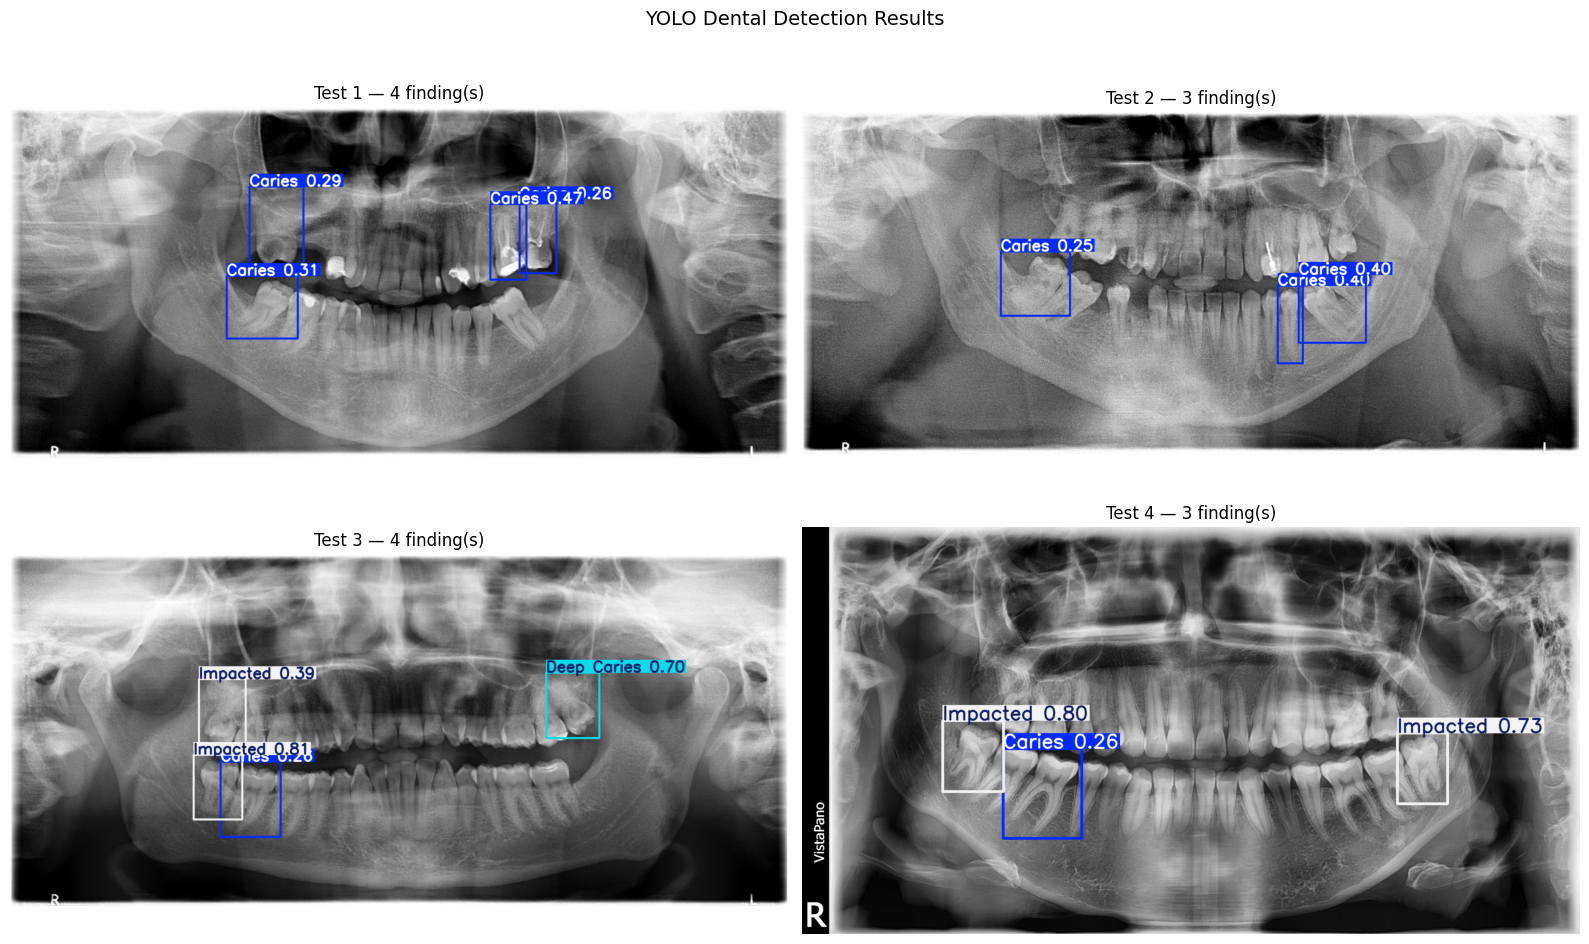

In [ ]:
test_imgs   = glob.glob('/content/dentex-2/test/images/*.jpg')
sample_test = random.sample(test_imgs, 4)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, img_path in enumerate(sample_test):
    results   = best_model.predict(img_path, conf=0.25, verbose=False)
    result    = results[0]
    annotated = result.plot()
    axes[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[i].set_title(f'Test {i+1} — {len(result.boxes)} finding(s)')
    axes[i].axis('off')

plt.suptitle('YOLO Dental Detection Results', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/dental_xray'

if os.path.exists(f'{DRIVE_PATH}/best_v2.pt'):
    best_model = YOLO(f'{DRIVE_PATH}/best_v2.pt')
    print("✅ Model loaded from Drive!")
else:
    print("❌ No model found in Drive — need to retrain")

✅ Model loaded from Drive!


In [ ]:
!pip install git+https://github.com/facebookresearch/sam2.git -q
print("✅ SAM2 installed!")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.7 MB/s eta 0:00:00
✅ SAM2 installed!


In [ ]:
DRIVE_PATH = '/content/drive/MyDrive/dental_xray'
os.makedirs('checkpoints', exist_ok=True)

SAM2_PATH = 'checkpoints/sam2_hiera_small.pt'

if os.path.exists(f'{DRIVE_PATH}/sam2_hiera_small.pt'):
    # Load from Drive
    print("📂 Found SAM2 weights in Drive — restoring...")
    shutil.copy(f'{DRIVE_PATH}/sam2_hiera_small.pt', SAM2_PATH)
    print("✅ SAM2 weights restored!")
else:
    # Download fresh
    print("⬇️  Downloading SAM2 weights...")
    !wget -q https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt \
         -O {SAM2_PATH}
    # Save to Drive
    shutil.copy(SAM2_PATH, f'{DRIVE_PATH}/sam2_hiera_small.pt')
    print("✅ SAM2 weights downloaded and saved to Drive!")

⬇️  Downloading SAM2 weights...
✅ SAM2 weights downloaded and saved to Drive!


In [ ]:
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

device = "cuda" if torch.cuda.is_available() else "cpu"

sam2_model = build_sam2(
    config_file = "sam2_hiera_s.yaml",
    ckpt_path   = "checkpoints/sam2_hiera_small.pt",
    device      = device
)

predictor = SAM2ImagePredictor(sam2_model)
print(f"✅ SAM2 loaded on {device}!")

✅ SAM2 loaded on cuda!


Glyph 129463 (\N{TOOTH}) missing from font(s) DejaVu Sans.
Glyph 129463 (\N{TOOTH}) missing from font(s) DejaVu Sans.


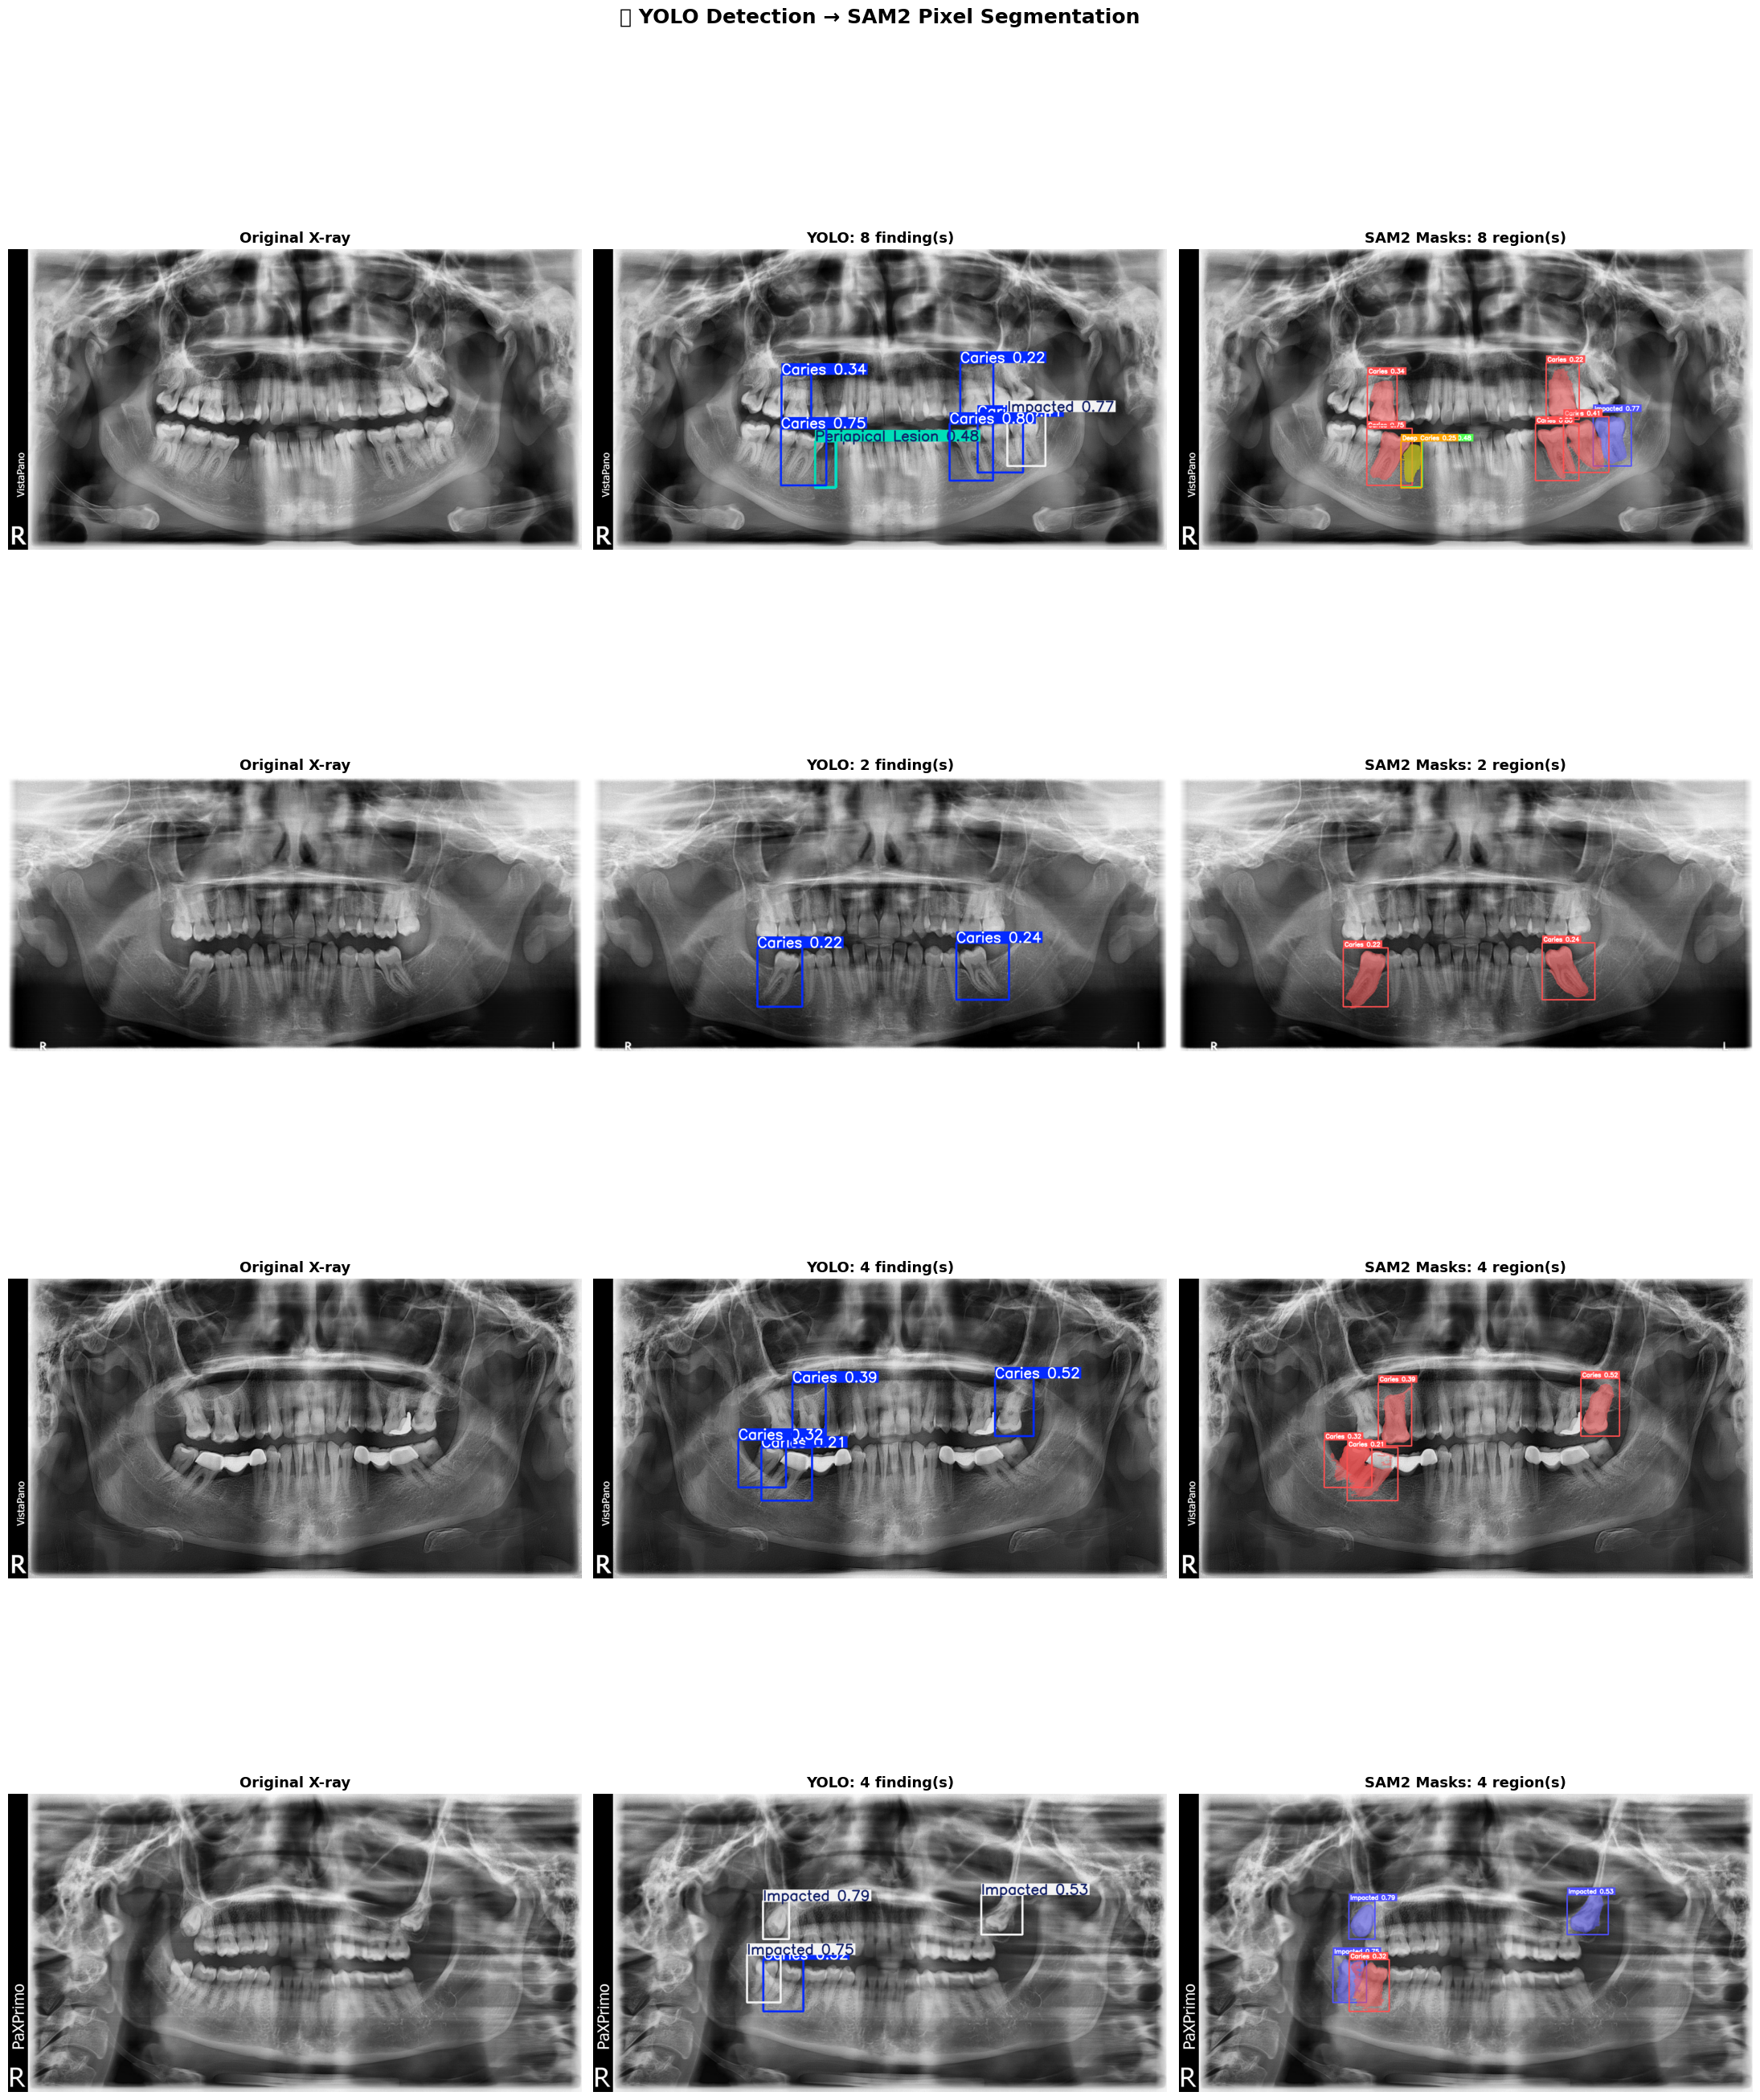

✅ Saved to Drive: /content/drive/MyDrive/dental_xray/yolo_sam2_final.png
✅ YOLO + SAM2 pipeline complete!


In [ ]:
CLASS_NAMES = ['Caries', 'Deep Caries', 'Impacted', 'Periapical Lesion']
COLORS = {
    0: (255, 80,  80),    # Caries        — red
    1: (255, 165,  0),    # Deep Caries   — orange
    2: (80,  80,  255),   # Impacted      — blue
    3: (80,  255, 80),    # Periapical    — green
}

def apply_mask(img, mask, color, alpha=0.5):
    """Blend colored mask directly onto image."""
    mask  = mask.astype(bool)
    color = np.array(color, dtype=np.uint8)
    img   = img.copy()
    img[mask] = (img[mask] * (1 - alpha) + color * alpha).astype(np.uint8)
    return img

def draw_label(img, text, x1, y1, color):
    """Draw label with solid background — always visible."""
    font       = cv2.FONT_HERSHEY_SIMPLEX
    scale      = 0.7
    thickness  = 2
    (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
    pad = 5
    # Background rectangle
    cv2.rectangle(img,
                  (x1, y1 - th - pad*2),
                  (x1 + tw + pad*2, y1),
                  color, -1)
    # White text on colored background
    cv2.putText(img, text,
                (x1 + pad, y1 - pad),
                font, scale,
                (255, 255, 255),
                thickness, cv2.LINE_AA)

# ── Run on 4 test images ─────────────────────────────────────
test_imgs   = glob.glob('/content/dentex-2/test/images/*.jpg')
sample_test = random.sample(test_imgs, 4)

fig, axes = plt.subplots(4, 3, figsize=(22, 28))

for idx, img_path in enumerate(sample_test):
    img     = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ── YOLO ─────────────────────────────────────────────────
    results   = best_model.predict(img_path, conf=0.20, verbose=False)
    result    = results[0]
    boxes     = result.boxes
    annotated = result.plot()

    # ── SAM2 ─────────────────────────────────────────────────
    predictor.set_image(img_rgb)

    # Col 0: Original
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title('Original X-ray', fontsize=13, fontweight='bold')
    axes[idx, 0].axis('off')

    # Col 1: YOLO boxes
    axes[idx, 1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[idx, 1].set_title(f'YOLO: {len(boxes)} finding(s)',
                           fontsize=13, fontweight='bold')
    axes[idx, 1].axis('off')

    # Col 2: SAM2 masks
    img_with_masks = img_rgb.copy()

    if len(boxes) > 0:
        sam_boxes = boxes.xyxy.cpu().numpy()
        cls_ids   = boxes.cls.cpu().numpy().astype(int)
        confs     = boxes.conf.cpu().numpy()

        for box, cls_id, conf in zip(sam_boxes, cls_ids, confs):
            color   = COLORS.get(int(cls_id), (255, 255, 0))
            x1, y1, x2, y2 = map(int, box)

            # SAM2 pixel mask
            masks, scores, _ = predictor.predict(
                box              = box,
                multimask_output = False
            )

            if len(masks) > 0:
                # Apply filled mask
                img_with_masks = apply_mask(
                    img_with_masks, masks[0], color, alpha=0.5
                )

            # Draw thick box border
            cv2.rectangle(img_with_masks,
                         (x1, y1), (x2, y2),
                         color, 3)

            # Draw visible label
            label = f"{CLASS_NAMES[int(cls_id)]} {conf:.2f}"
            draw_label(img_with_masks, label, x1, y1, color)

    axes[idx, 2].imshow(img_with_masks)
    axes[idx, 2].set_title(f'SAM2 Masks: {len(boxes)} region(s)',
                           fontsize=13, fontweight='bold')
    axes[idx, 2].axis('off')

plt.suptitle('🦷 YOLO Detection → SAM2 Pixel Segmentation',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()

# Save to Drive
save_path = f'{DRIVE_PATH}/yolo_sam2_final.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved to Drive: {save_path}")
print("✅ YOLO + SAM2 pipeline complete!")